# Problem Set C — Numerical Methods (Week 5 + Integration)

**This version includes solutions.**

**Course:** Programming and Numerical Methods for Economics (ECNM10115)  
**University of Edinburgh**

**Instructions:** Answer all questions. Show your working by including well-commented code. Each question is worth 10 marks, for a total of 100 marks.

| Question | Topic | Marks |
|----------|-------|-------|
| 1 | Root-finding: supply and demand | 10 |
| 2 | Root-finding: the Solow steady state | 10 |
| 3 | Unconstrained optimisation: comparing algorithms | 10 |
| 4 | Bounded optimisation: portfolio allocation | 10 |
| 5 | Root-finding meets simulation: the IS curve | 10 |
| 6 | Putting it all together: N-dimensional Rosenbrock | 10 |
| 7 | Newton’s method from scratch | 10 |
| 8 | Utility maximisation with budget constraints | 10 |
| 9 | Fixed-point iteration and the contraction mapping theorem | 10 |
| 10 | Capstone: two-sector general equilibrium | 10 |
| **Total** | | **100** |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize
from scipy.optimize import fsolve, minimize

---

## Question 1 — Root-Finding: Supply and Demand [10 marks]

Consider a competitive market with the following linear supply and demand functions:

$$Q_d(P) = a - bP, \quad Q_s(P) = c + dP$$

where $a = 100$, $b = 2$, $c = 10$, $d = 3$.

**(a)** [2 marks] Define Python functions for $Q_d(P)$ and $Q_s(P)$.

**(b)** [3 marks] Define the excess demand function $\text{ED}(P) = Q_d(P) - Q_s(P)$ and use `scipy.optimize.fsolve` to find the equilibrium price $P^*$. Compute the equilibrium quantity $Q^*$.

**(c)** [2 marks] Perform comparative statics: vary the demand intercept $a$ from 80 to 120 and compute the equilibrium price for each value.

**(d)** [3 marks] Produce two plots side by side: (i) a standard supply-and-demand diagram showing the equilibrium point, and (ii) equilibrium price as a function of the demand intercept $a$. Interpret the comparative statics result.

Supply and demand functions defined.
Equilibrium price:    P* = 18.0000
Equilibrium quantity: Q* = 64.0000
Analytical check:     P* = 18.0000


/tmp/ipykernel_13705/1722735794.py:30: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  P_star = fsolve(ed_a, 15.0)[0]


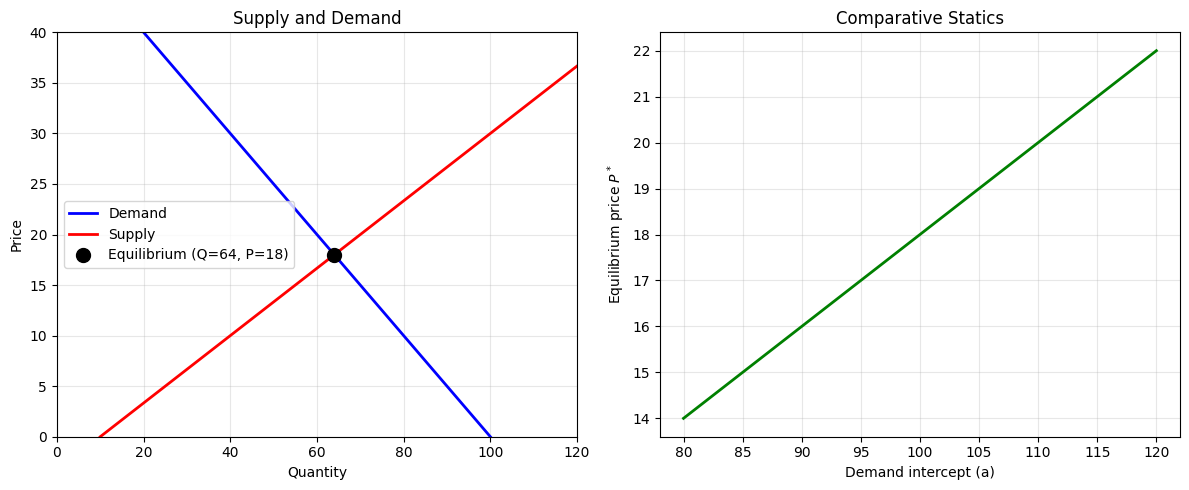

As 'a' increases, demand shifts right, raising P*. The relationship
is linear: dP*/da = 1/(b+d) = 1/5 = 0.2.


In [2]:
# --- Solution ---

# (a) Define supply and demand functions
def demand(P, a=100, b=2):
    return a - b * P

def supply(P, c=10, d=3):
    return c + d * P

print("Supply and demand functions defined.")

# (b) Excess demand and equilibrium via fsolve
def excess_demand(P):
    return demand(P) - supply(P)

P_eq = fsolve(excess_demand, 10.0)[0]
Q_eq = demand(P_eq)
print(f"Equilibrium price:    P* = {P_eq:.4f}")
print(f"Equilibrium quantity: Q* = {Q_eq:.4f}")

# Analytical check: P* = (a - c) / (b + d) = 90 / 5 = 18
P_check = (100 - 10) / (2 + 3)
print(f"Analytical check:     P* = {P_check:.4f}")

# (c) Comparative statics: vary demand intercept a
a_values = np.linspace(80, 120, 50)
P_eqs = []
for a_val in a_values:
    ed_a = lambda P, a=a_val: (a - 2 * P) - (10 + 3 * P)
    P_star = fsolve(ed_a, 15.0)[0]
    P_eqs.append(P_star)

# (d) Plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# (i) Supply-demand diagram
P_range = np.linspace(0, 40, 200)
axes[0].plot(demand(P_range), P_range, 'b-', linewidth=2, label='Demand')
axes[0].plot(supply(P_range), P_range, 'r-', linewidth=2, label='Supply')
axes[0].plot(Q_eq, P_eq, 'ko', markersize=10,
             label=f'Equilibrium (Q={Q_eq:.0f}, P={P_eq:.0f})')
axes[0].set_xlabel('Quantity')
axes[0].set_ylabel('Price')
axes[0].set_title('Supply and Demand')
axes[0].legend()
axes[0].set_xlim(0, 120)
axes[0].set_ylim(0, 40)
axes[0].grid(True, alpha=0.3)

# (ii) Comparative statics
axes[1].plot(a_values, P_eqs, 'g-', linewidth=2)
axes[1].set_xlabel('Demand intercept (a)')
axes[1].set_ylabel(r'Equilibrium price $P^*$')
axes[1].set_title('Comparative Statics')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Interpretation: As the demand intercept a increases, the demand curve
# shifts rightward, leading to a higher equilibrium price. The relationship
# is linear because both supply and demand are linear in P.
print("As 'a' increases, demand shifts right, raising P*. The relationship")
print("is linear: dP*/da = 1/(b+d) = 1/5 = 0.2.")

---

## Question 2 — Root-Finding: the Solow Steady State [10 marks]

The Solow growth model determines the steady-state capital per worker $k^*$ from the condition:

$$s f(k) = (n + \delta) k$$

where $f(k) = k^{\alpha}$ is the per-worker production function, $s$ is the savings rate, $n$ is the population growth rate, and $\delta$ is the depreciation rate.

Use parameter values $s = 0.3$, $\alpha = 0.33$, $n = 0.02$, $\delta = 0.05$.

**(a)** [2 marks] Define a function that returns the residual of the steady-state equation: $g(k) = s k^{\alpha} - (n + \delta) k$.

**(b)** [3 marks] Use `fsolve` to find $k^*$ numerically. Compare with the analytical solution $k^* = \left(\frac{s}{n + \delta}\right)^{1/(1-\alpha)}$ and compute steady-state output $y^* = (k^*)^{\alpha}$.

**(c)** [3 marks] Perform comparative statics: vary the savings rate $s$ from 0.1 to 0.5 and compute $k^*$ for each value.

**(d)** [2 marks] Plot (i) the Solow diagram showing $s f(k)$ and $(n+\delta)k$ with the steady state marked, and (ii) the relationship between $s$ and $k^*$.

Numerical k*  = 8.776437
Steady-state output y* = 2.047835
Analytical k* = 8.776437
Difference:     0.00e+00


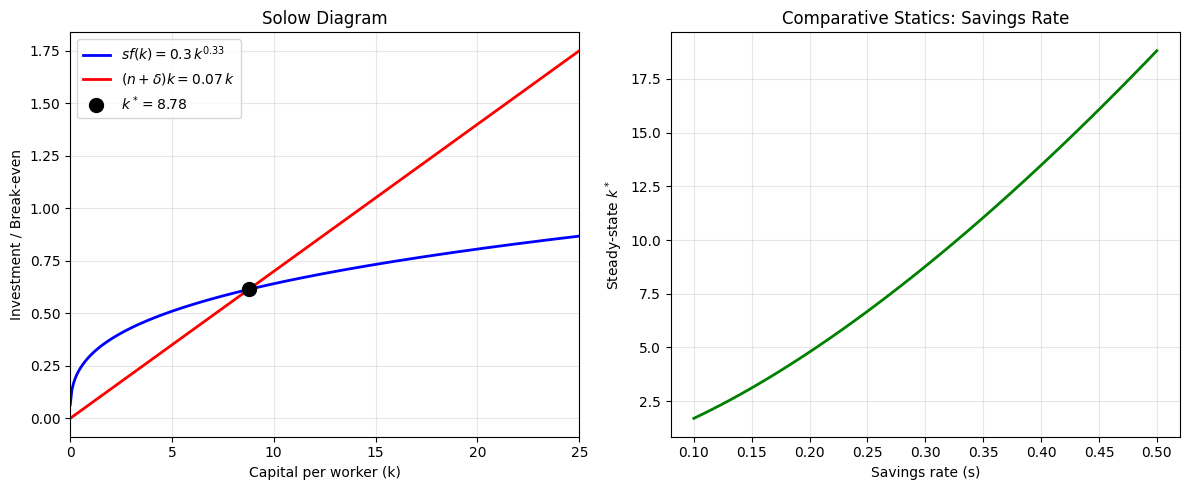

Higher savings rate => higher steady-state capital per worker.
The relationship is concave: k* = (s/0.07)^(1/0.67).


In [3]:
# --- Solution ---

# (a) Steady-state residual function
def solow_residual(k, s=0.3, alpha=0.33, n=0.02, delta=0.05):
    return s * k**alpha - (n + delta) * k

# (b) Numerical solution and comparison with analytical
# Note: use a good initial guess (k > 0) to avoid the trivial root k = 0
k_star = fsolve(solow_residual, 5.0)[0]
y_star = k_star**0.33
print(f"Numerical k*  = {k_star:.6f}")
print(f"Steady-state output y* = {y_star:.6f}")

# Analytical solution
s, alpha, n, delta = 0.3, 0.33, 0.02, 0.05
k_analytical = (s / (n + delta))**(1 / (1 - alpha))
y_analytical = k_analytical**alpha
print(f"Analytical k* = {k_analytical:.6f}")
print(f"Difference:     {abs(k_star - k_analytical):.2e}")

# (c) Comparative statics: vary savings rate s
s_values = np.linspace(0.1, 0.5, 50)
k_stars = []
for s_val in s_values:
    k_s = fsolve(solow_residual, 5.0, args=(s_val, 0.33, 0.02, 0.05))[0]
    k_stars.append(k_s)

# (d) Plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# (i) Solow diagram
k_range = np.linspace(0.01, 25, 300)
axes[0].plot(k_range, s * k_range**alpha, 'b-', linewidth=2,
             label=r'$sf(k) = 0.3\,k^{0.33}$')
axes[0].plot(k_range, (n + delta) * k_range, 'r-', linewidth=2,
             label=r'$(n+\delta)k = 0.07\,k$')
axes[0].plot(k_star, (n + delta) * k_star, 'ko', markersize=10,
             label=f'$k^* = {k_star:.2f}$')
axes[0].set_xlabel('Capital per worker (k)')
axes[0].set_ylabel('Investment / Break-even')
axes[0].set_title('Solow Diagram')
axes[0].legend()
axes[0].set_xlim(0, 25)
axes[0].grid(True, alpha=0.3)

# (ii) k* as a function of s
axes[1].plot(s_values, k_stars, 'g-', linewidth=2)
axes[1].set_xlabel('Savings rate (s)')
axes[1].set_ylabel(r'Steady-state $k^*$')
axes[1].set_title('Comparative Statics: Savings Rate')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Higher savings rate => higher steady-state capital per worker.")
print(f"The relationship is concave: k* = (s/0.07)^(1/0.67).")

---

## Question 3 — Unconstrained Optimisation: Comparing Algorithms [10 marks]

The **Rosenbrock function** is a classic test problem for optimisation algorithms:

$$f(x, y) = (1 - x)^2 + 100(y - x^2)^2$$

Its global minimum is at $(x^*, y^*) = (1, 1)$ where $f = 0$.

**(a)** [3 marks] Define the Rosenbrock function in Python. Create a contour plot over the region $x \in [-2, 2]$, $y \in [-1, 3]$, using logarithmically spaced contour levels. Mark the minimum.

**(b)** [4 marks] Starting from $x_0 = (-1.5, 2.0)$, minimise the Rosenbrock function using three methods: `Nelder-Mead`, `BFGS`, and `CG`. For each, report the solution $x^*$, the function value $f(x^*)$, and the number of function evaluations.

**(c)** [3 marks] Use the `callback` argument of `scipy.optimize.minimize` to record the function value at each iteration for all three methods. Plot the convergence curves (log scale) on the same axes and discuss which method converges fastest and why.

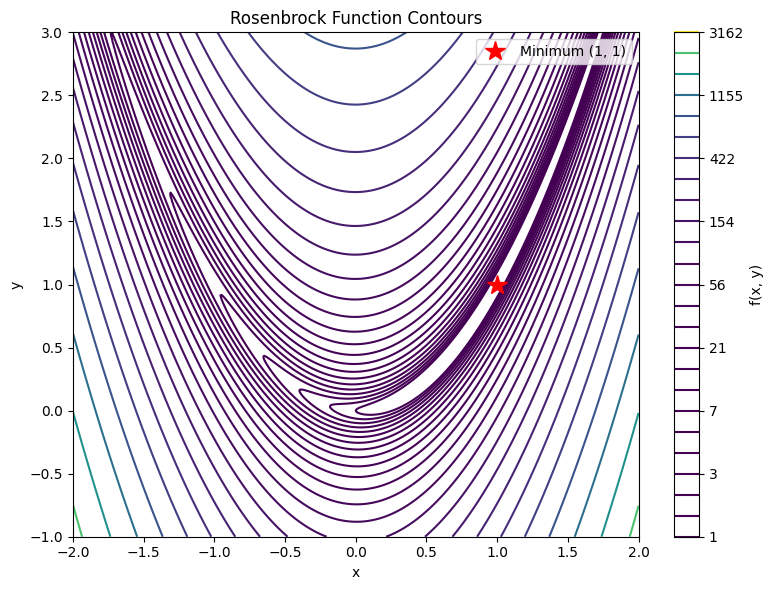

Method               x*[0]      x*[1]        f(x*)   nfev  Success
-----------------------------------------------------------------
Nelder-Mead       1.000005   1.000007     6.32e-10    179     True
BFGS              0.999996   0.999992     1.58e-11    168    False
CG                0.999995   0.999991     2.03e-11    214     True


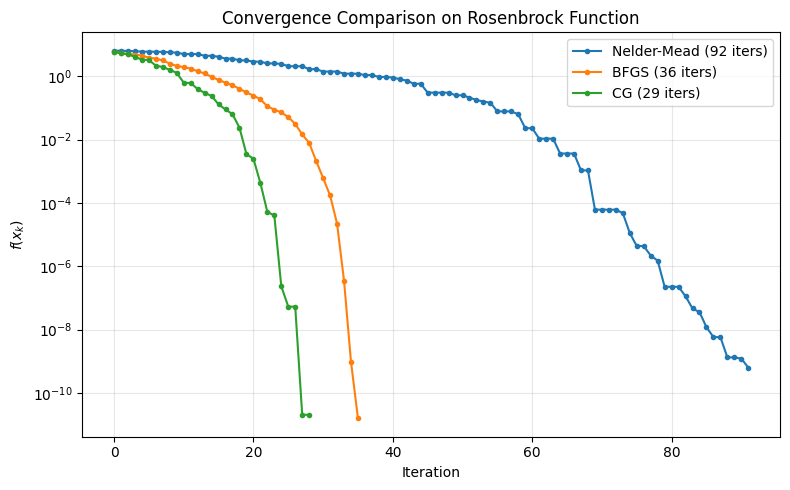


BFGS typically converges fastest because it uses gradient information
and approximates the Hessian (quasi-Newton). CG also uses gradients
but with a simpler update. Nelder-Mead is derivative-free and slower
but can handle non-smooth objectives.


In [4]:
# --- Solution ---

# (a) Define Rosenbrock and create contour plot
def rosenbrock(x):
    return (1 - x[0])**2 + 100 * (x[1] - x[0]**2)**2

x_grid = np.linspace(-2, 2, 400)
y_grid = np.linspace(-1, 3, 400)
X, Y = np.meshgrid(x_grid, y_grid)
Z = (1 - X)**2 + 100 * (Y - X**2)**2

fig, ax = plt.subplots(figsize=(8, 6))
levels = np.logspace(0, 3.5, 25)
cs = ax.contour(X, Y, Z, levels=levels, cmap='viridis')
ax.plot(1, 1, 'r*', markersize=15, label='Minimum (1, 1)')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Rosenbrock Function Contours')
ax.legend()
plt.colorbar(cs, ax=ax, label='f(x, y)')
plt.tight_layout()
plt.show()

# (b) Compare three optimisation methods
x0 = np.array([-1.5, 2.0])
methods = ['Nelder-Mead', 'BFGS', 'CG']

print(f"{'Method':<15s} {'x*[0]':>10s} {'x*[1]':>10s} {'f(x*)':>12s} {'nfev':>6s} {'Success':>8s}")
print("-" * 65)
for method in methods:
    res = minimize(rosenbrock, x0, method=method)
    print(f"{method:<15s} {res.x[0]:10.6f} {res.x[1]:10.6f} "
          f"{res.fun:12.2e} {res.nfev:6d} {str(res.success):>8s}")

# (c) Convergence analysis using callbacks
fig, ax = plt.subplots(figsize=(8, 5))

for method in methods:
    convergence = []
    def make_callback(store):
        def callback(xk):
            store.append(rosenbrock(xk))
        return callback
    cb = make_callback(convergence)
    res = minimize(rosenbrock, x0, method=method, callback=cb)
    ax.semilogy(range(len(convergence)), convergence, '-o', markersize=3,
                label=f'{method} ({len(convergence)} iters)')

ax.set_xlabel('Iteration')
ax.set_ylabel(r'$f(x_k)$')
ax.set_title('Convergence Comparison on Rosenbrock Function')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Discussion
print("\nBFGS typically converges fastest because it uses gradient information")
print("and approximates the Hessian (quasi-Newton). CG also uses gradients")
print("but with a simpler update. Nelder-Mead is derivative-free and slower")
print("but can handle non-smooth objectives.")

---

## Question 4 — Bounded Optimisation: Portfolio Allocation [10 marks]

Consider a portfolio of $n = 4$ assets with expected returns $\boldsymbol{\mu}$ and covariance matrix $\boldsymbol{\Sigma}$.

The portfolio variance is $\sigma_p^2 = \mathbf{w}^\top \boldsymbol{\Sigma} \mathbf{w}$ and the portfolio expected return is $r_p = \mathbf{w}^\top \boldsymbol{\mu}$, where $\mathbf{w}$ is the vector of portfolio weights.

Use the following data:

$$\boldsymbol{\mu} = \begin{pmatrix} 0.12 \\ 0.10 \\ 0.07 \\ 0.03 \end{pmatrix}, \quad
\boldsymbol{\Sigma} = \begin{pmatrix}
0.040 & 0.006 & 0.002 & 0.000 \\
0.006 & 0.025 & 0.004 & 0.001 \\
0.002 & 0.004 & 0.015 & 0.002 \\
0.000 & 0.001 & 0.002 & 0.008
\end{pmatrix}$$

**(a)** [2 marks] Define the portfolio variance and return as Python functions of the weight vector $\mathbf{w}$.

**(b)** [3 marks] Use `scipy.optimize.minimize` with `method='L-BFGS-B'` to minimise portfolio variance with bounds $0 \le w_i \le 1$. Report the solution and discuss why the result may not be a valid portfolio (hint: there is no constraint that weights sum to 1).

**(c)** [3 marks] Now use `method='SLSQP'` with bounds $0 \le w_i \le 1$, an equality constraint $\sum w_i = 1$, and an inequality constraint requiring expected return $\ge 0.08$. Report the optimal portfolio.

**(d)** [2 marks] Trace out the efficient frontier by varying the target return from 0.03 to 0.12 (using SLSQP). Plot portfolio standard deviation vs expected return and mark the solution from (c).

L-BFGS-B (bounds only):
  Weights:    [0.     0.     0.     0.0005]
  Variance:   0.000000
  Return:     0.000016
  Sum(w):     0.000522
  Note: L-BFGS-B cannot enforce equality constraints. Without
  sum(w)=1, the trivial solution w=0 minimises variance. L-BFGS-B
  handles only simple bounds, not general constraints.

SLSQP (bounds + constraints):
  Weights:    [0.2211 0.2691 0.2817 0.2282]
  Variance:   0.007321
  Std dev:    0.085563
  Return:     0.080000
  Sum(w):     1.000000


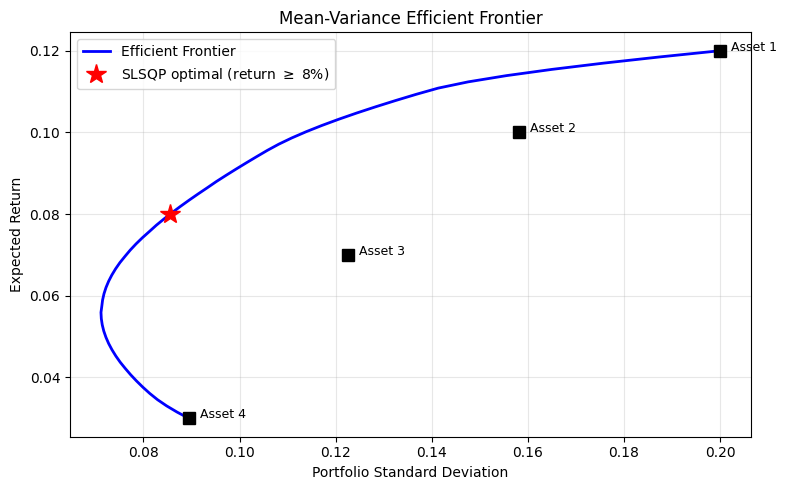

In [5]:
# --- Solution ---

# (a) Define portfolio functions
mu = np.array([0.12, 0.10, 0.07, 0.03])

cov_matrix = np.array([
    [0.040, 0.006, 0.002, 0.000],
    [0.006, 0.025, 0.004, 0.001],
    [0.002, 0.004, 0.015, 0.002],
    [0.000, 0.001, 0.002, 0.008]
])

def portfolio_variance(w):
    return w @ cov_matrix @ w

def portfolio_return(w):
    return w @ mu

n_assets = len(mu)
x0 = np.ones(n_assets) / n_assets
bounds = [(0, 1)] * n_assets

# (b) L-BFGS-B: bounds only, no equality constraint
res_lbfgsb = minimize(portfolio_variance, x0, method='L-BFGS-B', bounds=bounds)
print("L-BFGS-B (bounds only):")
print(f"  Weights:    {np.array2string(res_lbfgsb.x, precision=4)}")
print(f"  Variance:   {res_lbfgsb.fun:.6f}")
print(f"  Return:     {portfolio_return(res_lbfgsb.x):.6f}")
print(f"  Sum(w):     {np.sum(res_lbfgsb.x):.6f}")
print("  Note: L-BFGS-B cannot enforce equality constraints. Without")
print("  sum(w)=1, the trivial solution w=0 minimises variance. L-BFGS-B")
print("  handles only simple bounds, not general constraints.")

# (c) SLSQP: bounds + constraints
constraints = [
    {'type': 'eq',   'fun': lambda w: np.sum(w) - 1},           # weights sum to 1
    {'type': 'ineq', 'fun': lambda w: portfolio_return(w) - 0.08}  # return >= 8%
]

res_slsqp = minimize(portfolio_variance, x0, method='SLSQP',
                     bounds=bounds, constraints=constraints)
print("\nSLSQP (bounds + constraints):")
print(f"  Weights:    {np.array2string(res_slsqp.x, precision=4)}")
print(f"  Variance:   {res_slsqp.fun:.6f}")
print(f"  Std dev:    {np.sqrt(res_slsqp.fun):.6f}")
print(f"  Return:     {portfolio_return(res_slsqp.x):.6f}")
print(f"  Sum(w):     {np.sum(res_slsqp.x):.6f}")

# (d) Efficient frontier
target_returns = np.linspace(0.03, 0.12, 60)
efficient_stds = []
for target in target_returns:
    cons = [
        {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
        {'type': 'eq', 'fun': lambda w, t=target: portfolio_return(w) - t}
    ]
    res = minimize(portfolio_variance, x0, method='SLSQP',
                   bounds=bounds, constraints=cons)
    if res.success:
        efficient_stds.append(np.sqrt(res.fun))
    else:
        efficient_stds.append(np.nan)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(efficient_stds, target_returns, 'b-', linewidth=2, label='Efficient Frontier')
ax.plot(np.sqrt(res_slsqp.fun), portfolio_return(res_slsqp.x), 'r*',
        markersize=15, label='SLSQP optimal (return $\\geq$ 8%)')

# Plot individual assets
for i in range(n_assets):
    ax.plot(np.sqrt(cov_matrix[i, i]), mu[i], 'ks', markersize=8)
    ax.annotate(f'Asset {i+1}', (np.sqrt(cov_matrix[i, i]), mu[i]),
                textcoords="offset points", xytext=(8, 0), fontsize=9)

ax.set_xlabel('Portfolio Standard Deviation')
ax.set_ylabel('Expected Return')
ax.set_title('Mean-Variance Efficient Frontier')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---

## Question 5 — Root-Finding Meets Simulation: the IS Curve [10 marks]

Consider a simple Keynesian IS model. Goods-market equilibrium requires:

$$Y = C(Y - T) + I(r) + G$$

where consumption is $C = c_0 + c_1(Y - T)$, investment is $I = I_0 - br$, and $G$ is government spending.

Use parameter values: $c_0 = 50$, $c_1 = 0.6$, $I_0 = 200$, $b = 50$, $G = 100$, $T = 100$.

**(a)** [2 marks] Define a function `IS_residual(Y, r)` that returns the excess demand $C + I + G - Y$. At equilibrium, this equals zero.

**(b)** [3 marks] For $r = 0.05$, use `fsolve` to find equilibrium output $Y^*$. Verify against the analytical solution $Y^* = \frac{c_0 - c_1 T + I_0 - b r + G}{1 - c_1}$.

**(c)** [3 marks] Compute the fiscal multiplier $\Delta Y / \Delta G$ by varying $G$ from 50 to 200 and solving for $Y^*$ at each value (holding $r = 0.05$). Compare the numerical multiplier to the theoretical value $1/(1 - c_1)$.

**(d)** [2 marks] Plot the IS curve: for each interest rate $r \in [0, 0.15]$, solve for equilibrium $Y^*$. Plot with $Y$ on the horizontal axis and $r$ on the vertical axis. Also plot the fiscal multiplier relationship.

Numerical Y*(r=0.05)  = 718.7500
Analytical Y*(r=0.05) = 718.7500
Difference:             0.00e+00

Numerical multiplier:    2.5000
Theoretical 1/(1-c1):    2.5000


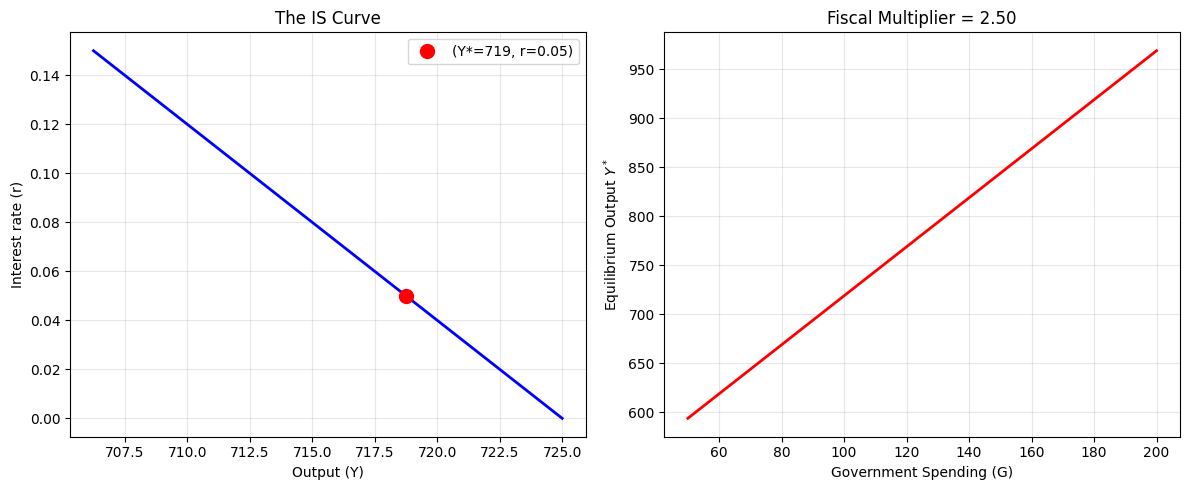

The IS curve slopes downward: higher r reduces investment,
lowering equilibrium output. The fiscal multiplier is 2.5,
meaning each unit increase in G raises Y by 2.5 units.


In [6]:
# --- Solution ---

# Parameters
c0, c1 = 50, 0.6       # Consumption: C = c0 + c1*(Y-T)
I0, b_inv = 200, 50    # Investment: I = I0 - b*r
G = 100                 # Government spending
T = 100                 # Taxes

# (a) IS residual function
def IS_residual(Y, r):
    C = c0 + c1 * (Y - T)
    I = I0 - b_inv * r
    return C + I + G - Y   # excess demand; zero at equilibrium

# (b) Solve for equilibrium at r = 0.05
r0 = 0.05
Y_eq = fsolve(IS_residual, 500, args=(r0,))[0]
print(f"Numerical Y*(r=0.05)  = {Y_eq:.4f}")

# Analytical solution
Y_analytical = (c0 - c1 * T + I0 - b_inv * r0 + G) / (1 - c1)
print(f"Analytical Y*(r=0.05) = {Y_analytical:.4f}")
print(f"Difference:             {abs(Y_eq - Y_analytical):.2e}")

# (c) Fiscal multiplier
G_values = np.linspace(50, 200, 80)
Y_eqs_G = []
for G_val in G_values:
    def is_eq(Y, G_val=G_val):
        C = c0 + c1 * (Y - T)
        I = I0 - b_inv * r0
        return C + I + G_val - Y
    Y_s = fsolve(is_eq, 500)[0]
    Y_eqs_G.append(Y_s)

# Numerical multiplier from slope
multiplier_num = (Y_eqs_G[-1] - Y_eqs_G[0]) / (G_values[-1] - G_values[0])
multiplier_theory = 1 / (1 - c1)
print(f"\nNumerical multiplier:    {multiplier_num:.4f}")
print(f"Theoretical 1/(1-c1):    {multiplier_theory:.4f}")

# (d) Plot IS curve and multiplier
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# IS curve: Y*(r) for r in [0, 0.15]
r_range = np.linspace(0, 0.15, 100)
Y_IS = []
for r in r_range:
    Y_r = fsolve(IS_residual, 500, args=(r,))[0]
    Y_IS.append(Y_r)

axes[0].plot(Y_IS, r_range, 'b-', linewidth=2)
axes[0].plot(Y_eq, r0, 'ro', markersize=10, label=f'(Y*={Y_eq:.0f}, r={r0})')
axes[0].set_xlabel('Output (Y)')
axes[0].set_ylabel('Interest rate (r)')
axes[0].set_title('The IS Curve')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Multiplier relationship
axes[1].plot(G_values, Y_eqs_G, 'r-', linewidth=2)
axes[1].set_xlabel('Government Spending (G)')
axes[1].set_ylabel(r'Equilibrium Output $Y^*$')
axes[1].set_title(f'Fiscal Multiplier = {multiplier_num:.2f}')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("The IS curve slopes downward: higher r reduces investment,")
print("lowering equilibrium output. The fiscal multiplier is 2.5,")
print("meaning each unit increase in G raises Y by 2.5 units.")

---

## Question 6 — Putting It All Together: N-Dimensional Rosenbrock [10 marks]

The $N$-dimensional generalisation of the Rosenbrock function is:

$$f(\mathbf{x}) = \sum_{i=1}^{N-1} \left[ 100 \left(x_{i+1} - x_i^2\right)^2 + (1 - x_i)^2 \right]$$

The global minimum is at $\mathbf{x}^* = (1, 1, \ldots, 1)$ where $f = 0$.

**(a)** [2 marks] Define a Python function for the $N$-dimensional Rosenbrock function.

**(b)** [3 marks] Using `method='L-BFGS-B'` and starting from $\mathbf{x}_0 = \mathbf{0}$, minimise the function for $N = 2, 5, 10, 20, 50$. Report $f(x^*)$, the number of function evaluations, and the wall-clock time for each.

**(c)** [3 marks] Analyse the computational scaling: create log-log plots of (i) function evaluations vs $N$ and (ii) wall-clock time vs $N$.

**(d)** [2 marks] Verify the solutions by computing $\max_i |x_i^* - 1|$ for each $N$. Discuss the challenges of high-dimensional optimisation.

   N        f(x*)     nfev   Time (s)  Success
----------------------------------------------
   2     9.14e-12       78     0.0038     True
   5     3.42e-11      276     0.0203     True
  10     1.96e-11     1012     0.0261     True
  20     4.88e-10     2730     0.0953     True


  50     2.52e-08    15045     0.7947    False


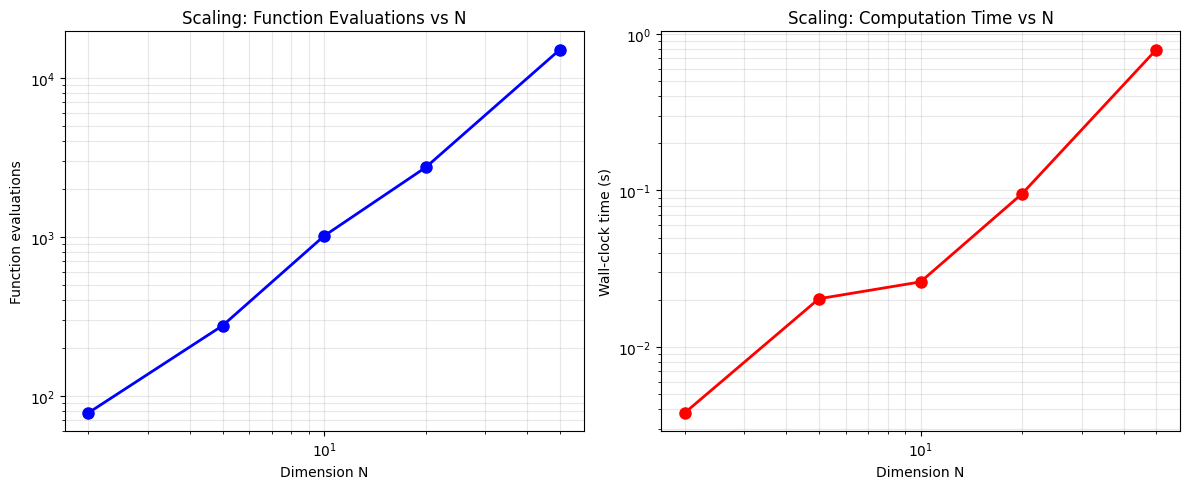


Solution verification:
   N   max|x_i - 1|
----------------------
   2       6.05e-06
   5       9.92e-06
  10       7.58e-06
  20       1.33e-05
  50       3.76e-06

As N increases, the optimisation becomes harder: more function
evaluations are needed, and the solution accuracy may decrease.
This illustrates the 'curse of dimensionality' in optimisation.


In [7]:
# --- Solution ---
from time import time

# (a) N-dimensional Rosenbrock function
def rosenbrock_nd(x):
    return sum(100 * (x[i+1] - x[i]**2)**2 + (1 - x[i])**2
               for i in range(len(x) - 1))

# (b) Optimise for different dimensions
dimensions = [2, 5, 10, 20, 50]
results_nd = {}

print(f"{'N':>4s} {'f(x*)':>12s} {'nfev':>8s} {'Time (s)':>10s} {'Success':>8s}")
print("-" * 46)
for N in dimensions:
    x0 = np.zeros(N)
    t0 = time()
    res = minimize(rosenbrock_nd, x0, method='L-BFGS-B')
    elapsed = time() - t0
    results_nd[N] = {'result': res, 'time': elapsed}
    print(f"{N:4d} {res.fun:12.2e} {res.nfev:8d} {elapsed:10.4f} {str(res.success):>8s}")

# (c) Scaling analysis
nfevs = [results_nd[N]['result'].nfev for N in dimensions]
times = [results_nd[N]['time'] for N in dimensions]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].loglog(dimensions, nfevs, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Dimension N')
axes[0].set_ylabel('Function evaluations')
axes[0].set_title('Scaling: Function Evaluations vs N')
axes[0].grid(True, alpha=0.3, which='both')

axes[1].loglog(dimensions, times, 'ro-', linewidth=2, markersize=8)
axes[1].set_xlabel('Dimension N')
axes[1].set_ylabel('Wall-clock time (s)')
axes[1].set_title('Scaling: Computation Time vs N')
axes[1].grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()

# (d) Verify solutions
print("\nSolution verification:")
print(f"{'N':>4s} {'max|x_i - 1|':>14s}")
print("-" * 22)
for N in dimensions:
    x_star = results_nd[N]['result'].x
    max_error = np.max(np.abs(x_star - 1.0))
    print(f"{N:4d} {max_error:14.2e}")

print("\nAs N increases, the optimisation becomes harder: more function")
print("evaluations are needed, and the solution accuracy may decrease.")
print("This illustrates the 'curse of dimensionality' in optimisation.")

---

## Question 7 — Newton’s Method from Scratch [10 marks]

Newton’s method for finding a root of $f(x) = 0$ uses the iteration:

$$x_{n+1} = x_n - \frac{f(x_n)}{f'(x_n)}$$

The **internal rate of return (IRR)** of a cash-flow stream $(C_0, C_1, \ldots, C_T)$ is the rate $r$ satisfying:

$$\text{NPV}(r) = \sum_{t=0}^{T} \frac{C_t}{(1+r)^t} = 0$$

Use the cash-flow stream $C = (-1000, 300, 300, 300, 300, 300)$.

**(a)** [3 marks] Implement Newton’s method from scratch (do **not** use `scipy`). Your function should accept $f$, $f'$, an initial guess $x_0$, a tolerance, and a maximum number of iterations. It should return the root and a history of iterates.

**(b)** [3 marks] Define the NPV function and its derivative analytically:

$$\text{NPV}'(r) = \sum_{t=1}^{T} \frac{-t \, C_t}{(1+r)^{t+1}}$$

Apply your Newton’s method to find the IRR. Report the IRR and the number of iterations to converge.

**(c)** [2 marks] Implement the **bisection method** and use it to find the same IRR with bracket $[0, 0.5]$. Compare the number of iterations required.

**(d)** [2 marks] Plot $|f(x_n)|$ vs iteration number for both methods on the same axes (log scale on the $y$-axis). Discuss the convergence rates.

IRR (Newton's method): 0.1523823712  (15.238237%)
Iterations:            5
NPV at IRR:            -1.42e-13

IRR (Bisection):       0.1523823712  (15.238237%)
Iterations:            39


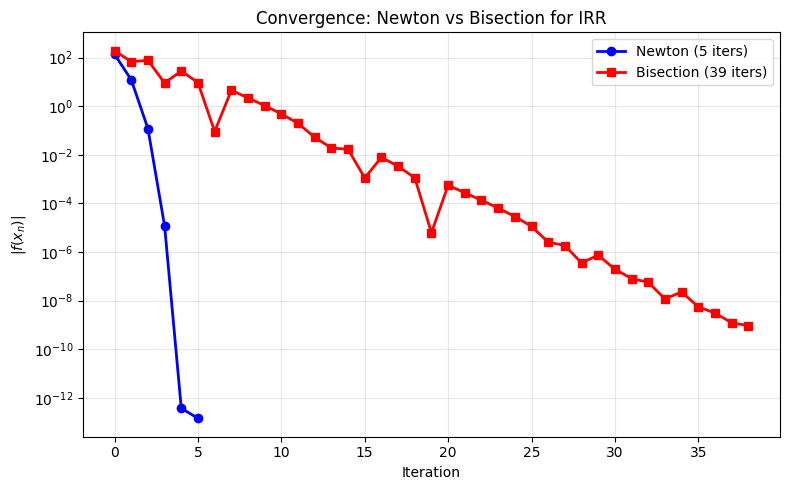


Newton's method converges quadratically (error squares each step),
requiring far fewer iterations than bisection, which converges
linearly (halving the bracket each step). However, Newton requires
the derivative and a good initial guess, while bisection is robust
given a valid bracket.


In [8]:
# --- Solution ---

# (a) Implement Newton's method from scratch
def newton_method(f, f_prime, x0, tol=1e-12, max_iter=100):
    """Newton's method for scalar root-finding.

    Returns (root, history) where history is a list of (x_n, |f(x_n)|).
    """
    x = x0
    history = [(x, abs(f(x)))]
    for i in range(max_iter):
        fx = f(x)
        fpx = f_prime(x)
        if abs(fpx) < 1e-15:
            print("Warning: derivative near zero at iteration", i)
            break
        x_new = x - fx / fpx
        history.append((x_new, abs(f(x_new))))
        if abs(x_new - x) < tol:
            break
        x = x_new
    return x_new, history

# (b) Define NPV and its derivative; find IRR
cash_flows = [-1000, 300, 300, 300, 300, 300]

def npv(r):
    return sum(cf / (1 + r)**t for t, cf in enumerate(cash_flows))

def npv_derivative(r):
    return sum(-t * cf / (1 + r)**(t + 1) for t, cf in enumerate(cash_flows))

irr_newton, newton_hist = newton_method(npv, npv_derivative, 0.10)
print(f"IRR (Newton's method): {irr_newton:.10f}  ({irr_newton*100:.6f}%)")
print(f"Iterations:            {len(newton_hist) - 1}")
print(f"NPV at IRR:            {npv(irr_newton):.2e}")

# (c) Implement bisection method
def bisection_method(f, a, b, tol=1e-12, max_iter=100):
    """Bisection method for root-finding on [a, b].

    Requires f(a) * f(b) < 0.
    Returns (root, history) where history is a list of (mid, |f(mid)|).
    """
    assert f(a) * f(b) < 0, "f(a) and f(b) must have opposite signs"
    history = []
    for i in range(max_iter):
        mid = (a + b) / 2.0
        f_mid = f(mid)
        history.append((mid, abs(f_mid)))
        if abs(f_mid) < tol or (b - a) / 2.0 < tol:
            break
        if f(a) * f_mid < 0:
            b = mid
        else:
            a = mid
    return mid, history

irr_bisect, bisect_hist = bisection_method(npv, 0.0, 0.5)
print(f"\nIRR (Bisection):       {irr_bisect:.10f}  ({irr_bisect*100:.6f}%)")
print(f"Iterations:            {len(bisect_hist)}")

# (d) Convergence plot
fig, ax = plt.subplots(figsize=(8, 5))

newton_errors = [h[1] for h in newton_hist]
bisect_errors = [h[1] for h in bisect_hist]

ax.semilogy(range(len(newton_errors)), newton_errors, 'bo-', linewidth=2,
            markersize=6, label=f'Newton ({len(newton_hist)-1} iters)')
ax.semilogy(range(len(bisect_errors)), bisect_errors, 'rs-', linewidth=2,
            markersize=6, label=f'Bisection ({len(bisect_hist)} iters)')

ax.set_xlabel('Iteration')
ax.set_ylabel(r'$|f(x_n)|$')
ax.set_title("Convergence: Newton vs Bisection for IRR")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nNewton's method converges quadratically (error squares each step),")
print("requiring far fewer iterations than bisection, which converges")
print("linearly (halving the bracket each step). However, Newton requires")
print("the derivative and a good initial guess, while bisection is robust")
print("given a valid bracket.")

---

## Question 8 — Utility Maximisation with Budget Constraints [10 marks]

A consumer maximises Cobb–Douglas utility:

$$U(x_1, x_2) = x_1^{\alpha} \, x_2^{1-\alpha}$$

subject to the budget constraint $p_1 x_1 + p_2 x_2 = m$.

Use parameter values $\alpha = 0.4$, $p_1 = 2$, $p_2 = 3$, $m = 120$.

**(a)** [3 marks] Solve analytically using the **Lagrangian**:

$$\mathcal{L} = x_1^{\alpha} \, x_2^{1-\alpha} - \lambda(p_1 x_1 + p_2 x_2 - m)$$

Derive the first-order conditions and show that the Marshallian demand functions are $x_1^* = \alpha m / p_1$ and $x_2^* = (1-\alpha) m / p_2$. Compute the optimal bundle.

**(b)** [3 marks] Solve numerically using `scipy.optimize.minimize` with `method='SLSQP'`. Set up the budget as an equality constraint and include bounds to ensure $x_1, x_2 > 0$. Verify that the numerical and analytical solutions match.

**(c)** [2 marks] Compute the **demand curve** for good 1: vary $p_1$ from 0.5 to 10 (holding $p_2 = 3$ and $m = 120$ fixed) and solve for $x_1^*$ numerically at each price. Plot with $p_1$ on the vertical axis.

**(d)** [2 marks] Compute the **Engel curves**: vary income $m$ from 20 to 300 (holding prices fixed) and plot $x_1^*$ and $x_2^*$ as functions of $m$.

Analytical solution (Lagrangian):
  x1* = alpha * m / p1 = 0.4 * 120.0 / 2.0 = 24.0000
  x2* = (1-alpha) * m / p2 = 0.6 * 120.0 / 3.0 = 24.0000
  U(x1*, x2*) = 24.0000
  Budget check: p1*x1 + p2*x2 = 120.0000 = m

Numerical solution (SLSQP):
  x1* = 24.0051
  x2* = 23.9966
  U    = 24.0000
  Budget: p1*x1 + p2*x2 = 120.0000
  Max difference from analytical: 5.13e-03


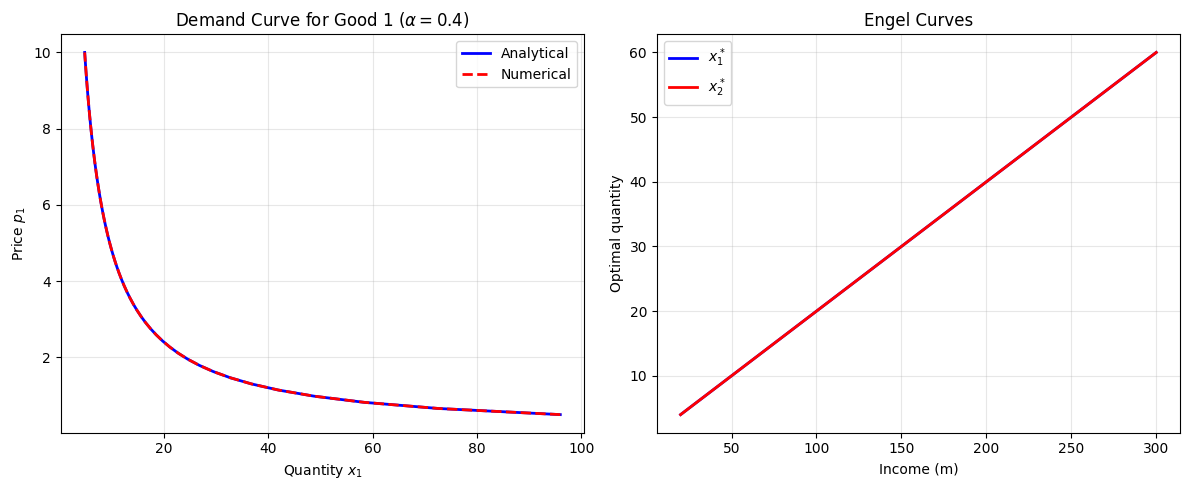

With Cobb-Douglas utility, demand for each good is linear in income
and inversely proportional to its own price. The income share spent
on good 1 is constant at alpha = 0.4.


In [9]:
# --- Solution ---

# Parameters
alpha = 0.4
p1, p2, m = 2.0, 3.0, 120.0

# (a) Analytical solution via Lagrangian
# FOC_1: alpha * x1^(alpha-1) * x2^(1-alpha) = lambda * p1
# FOC_2: (1-alpha) * x1^alpha * x2^(-alpha) = lambda * p2
# Dividing: [alpha/(1-alpha)] * (x2/x1) = p1/p2
# => x2 = [(1-alpha)/alpha] * (p1/p2) * x1
# Substituting into budget: p1*x1 + p2 * [(1-alpha)/alpha] * (p1/p2) * x1 = m
# => p1*x1 * [1 + (1-alpha)/alpha] = m
# => p1*x1 / alpha = m
# => x1* = alpha * m / p1,  x2* = (1-alpha) * m / p2

x1_analytical = alpha * m / p1
x2_analytical = (1 - alpha) * m / p2
U_analytical = x1_analytical**alpha * x2_analytical**(1 - alpha)

print("Analytical solution (Lagrangian):")
print(f"  x1* = alpha * m / p1 = {alpha} * {m} / {p1} = {x1_analytical:.4f}")
print(f"  x2* = (1-alpha) * m / p2 = {1-alpha} * {m} / {p2} = {x2_analytical:.4f}")
print(f"  U(x1*, x2*) = {U_analytical:.4f}")
print(f"  Budget check: p1*x1 + p2*x2 = {p1*x1_analytical + p2*x2_analytical:.4f} = m")

# (b) Numerical solution with SLSQP
def neg_utility(x):
    # Minimise negative utility (= maximise utility)
    return -(x[0]**alpha * x[1]**(1 - alpha))

budget_constraint = {'type': 'eq', 'fun': lambda x: p1*x[0] + p2*x[1] - m}
bounds_u = [(1e-6, None), (1e-6, None)]  # positive consumption

x0_u = np.array([m / (2*p1), m / (2*p2)])
res_u = minimize(neg_utility, x0_u, method='SLSQP',
                 bounds=bounds_u, constraints=budget_constraint)

print("\nNumerical solution (SLSQP):")
print(f"  x1* = {res_u.x[0]:.4f}")
print(f"  x2* = {res_u.x[1]:.4f}")
print(f"  U    = {-res_u.fun:.4f}")
print(f"  Budget: p1*x1 + p2*x2 = {p1*res_u.x[0] + p2*res_u.x[1]:.4f}")

max_diff = max(abs(res_u.x[0] - x1_analytical), abs(res_u.x[1] - x2_analytical))
print(f"  Max difference from analytical: {max_diff:.2e}")

# (c) Demand curve for good 1: vary p1
p1_values = np.linspace(0.5, 10, 60)
x1_demand_analytical = alpha * m / p1_values
x1_demand_numerical = []

for p in p1_values:
    cons = {'type': 'eq', 'fun': lambda x, p=p: p*x[0] + p2*x[1] - m}
    res = minimize(neg_utility, [m/(2*p), m/(2*p2)], method='SLSQP',
                   bounds=[(1e-6, None), (1e-6, None)], constraints=cons)
    x1_demand_numerical.append(res.x[0])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(x1_demand_analytical, p1_values, 'b-', linewidth=2, label='Analytical')
axes[0].plot(x1_demand_numerical, p1_values, 'r--', linewidth=2, label='Numerical')
axes[0].set_xlabel(r'Quantity $x_1$')
axes[0].set_ylabel(r'Price $p_1$')
axes[0].set_title(r'Demand Curve for Good 1 ($\alpha=0.4$)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# (d) Engel curves: vary income m
m_values = np.linspace(20, 300, 60)
x1_engel = alpha * m_values / p1
x2_engel = (1 - alpha) * m_values / p2

axes[1].plot(m_values, x1_engel, 'b-', linewidth=2, label=r'$x_1^*$')
axes[1].plot(m_values, x2_engel, 'r-', linewidth=2, label=r'$x_2^*$')
axes[1].set_xlabel('Income (m)')
axes[1].set_ylabel('Optimal quantity')
axes[1].set_title('Engel Curves')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("With Cobb-Douglas utility, demand for each good is linear in income")
print("and inversely proportional to its own price. The income share spent")
print(f"on good 1 is constant at alpha = {alpha}.")

---

## Question 9 — Fixed-Point Iteration and the Contraction Mapping Theorem [10 marks]

**Fixed-point iteration** finds a solution to $x = g(x)$ via the recursion $x_{n+1} = g(x_n)$.

The **Banach fixed-point theorem** (contraction mapping theorem) guarantees convergence when $|g'(x^*)| < 1$.

**(a)** [2 marks] Write a Python function `fixed_point_iteration(g, x0, tol, max_iter)` that implements the recursion and returns the fixed point and the full history of iterates.

**(b)** [3 marks] Consider a cobweb model of a market with adaptive expectations. Supply responds to last period’s price:

$$Q_s(P_{t}) = 2 + 3P_t, \quad Q_d(P_{t+1}) = 10 - 2P_{t+1}$$

Setting $Q_s(P_t) = Q_d(P_{t+1})$ gives the iteration $P_{t+1} = g(P_t) = (8 - 2P_t)/3$. Use your function to find the equilibrium price starting from $P_0 = 5$.

**(c)** [3 marks] Verify the Banach condition: compute $|g'(P^*)|$ and confirm it is less than 1. Then consider a steeper supply curve that gives $P_{t+1} = h(P_t) = 16 - 4P_t$. Show that $|h'(P^*)| > 1$ and demonstrate numerically that the iteration diverges.

**(d)** [2 marks] Plot the iterates for both the convergent and divergent cases (with the fixed point marked). Write a brief note connecting fixed-point iteration to **value function iteration** in dynamic programming (a preview of Week 8).

Convergent case: g(P) = (8 - 2P)/3
  Fixed point: P* = 1.600000
  Converged:   True
  Iterations:  63
  Analytical:  P* = 1.6

Banach condition for g:
  g'(P) = -2/3,  |g'(P*)| = 0.6667 < 1  =>  CONTRACTION

Divergent case: h(P) = 16 - 4P
  h'(P) = -4,  |h'(P*)| = 4.0000 > 1  =>  NOT A CONTRACTION
  Converged: False
  Analytical P* = 3.2
  Iterates diverge from P* = 3.2


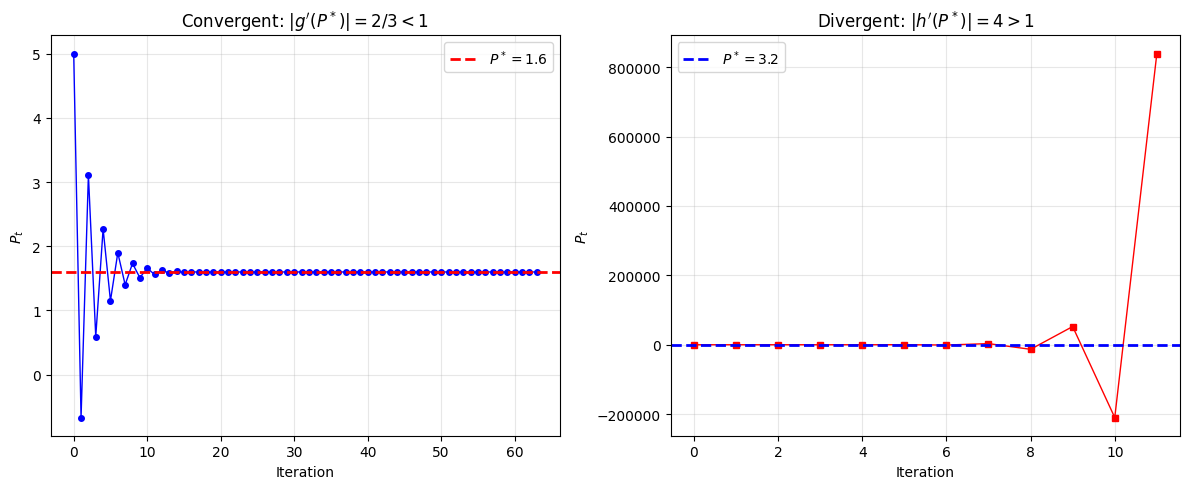


--- Connection to Value Function Iteration (Week 8 preview) ---
In dynamic programming, the Bellman equation V = T(V) defines the
value function as a fixed point of the Bellman operator T.
Under Blackwell's sufficient conditions, T is a contraction mapping,
so V_{n+1} = T(V_n) converges to the unique fixed point V*.
The contraction mapping theorem guarantees both existence and
uniqueness of the solution, just as in this simpler scalar example.


In [10]:
# --- Solution ---

# (a) Implement fixed-point iteration
def fixed_point_iteration(g, x0, tol=1e-10, max_iter=200):
    """Fixed-point iteration: x_{n+1} = g(x_n).

    Returns (fixed_point, history, converged).
    """
    x = x0
    history = [x]
    converged = False
    for i in range(max_iter):
        x_new = g(x)
        history.append(x_new)
        if abs(x_new - x) < tol:
            converged = True
            break
        if abs(x_new) > 1e10:  # overflow protection
            break
        x = x_new
    return x_new, history, converged

# (b) Cobweb model: convergent case
# Qs = 2 + 3*Pt, Qd = 10 - 2*P_{t+1}
# Equilibrium: Qs = Qd => 2 + 3*Pt = 10 - 2*P_{t+1}
# => P_{t+1} = (8 - 2*Pt) / 3

def g_contract(P):
    return (8 - 2*P) / 3.0

P_star_c, hist_c, conv_c = fixed_point_iteration(g_contract, 5.0)
print(f"Convergent case: g(P) = (8 - 2P)/3")
print(f"  Fixed point: P* = {P_star_c:.6f}")
print(f"  Converged:   {conv_c}")
print(f"  Iterations:  {len(hist_c) - 1}")

# Analytical: P* = (8 - 2P*)/3 => 3P* = 8 - 2P* => 5P* = 8 => P* = 1.6
print(f"  Analytical:  P* = {8/5}")

# (c) Verify Banach condition
# g'(P) = -2/3, so |g'(P*)| = 2/3 < 1  =>  contraction
print(f"\nBanach condition for g:")
print(f"  g'(P) = -2/3,  |g'(P*)| = {abs(-2/3):.4f} < 1  =>  CONTRACTION")

# Divergent case: steeper supply
# P_{t+1} = h(P) = 16 - 4*P
# Fixed point: P* = 16 - 4P* => 5P* = 16 => P* = 3.2
# h'(P) = -4, |h'(P*)| = 4 > 1  =>  NOT a contraction

def h_diverge(P):
    return 16 - 4*P

P_star_d, hist_d, conv_d = fixed_point_iteration(h_diverge, 3.0, max_iter=20)
print(f"\nDivergent case: h(P) = 16 - 4P")
print(f"  h'(P) = -4,  |h'(P*)| = {abs(-4):.4f} > 1  =>  NOT A CONTRACTION")
print(f"  Converged: {conv_d}")
print(f"  Analytical P* = {16/5}")
print(f"  Iterates diverge from P* = 3.2")

# (d) Plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Convergent case
axes[0].plot(hist_c, 'bo-', linewidth=1, markersize=4)
axes[0].axhline(y=1.6, color='r', linestyle='--', linewidth=2, label=r"$P^* = 1.6$")
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel(r'$P_t$')
axes[0].set_title(r"Convergent: $|g'(P^*)| = 2/3 < 1$")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Divergent case
n_show = min(12, len(hist_d))
axes[1].plot(range(n_show), hist_d[:n_show], 'rs-', linewidth=1, markersize=4)
axes[1].axhline(y=3.2, color='b', linestyle='--', linewidth=2, label=r"$P^* = 3.2$")
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel(r'$P_t$')
axes[1].set_title(r"Divergent: $|h'(P^*)| = 4 > 1$")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Connection to value function iteration
print("\n--- Connection to Value Function Iteration (Week 8 preview) ---")
print("In dynamic programming, the Bellman equation V = T(V) defines the")
print("value function as a fixed point of the Bellman operator T.")
print("Under Blackwell's sufficient conditions, T is a contraction mapping,")
print("so V_{n+1} = T(V_n) converges to the unique fixed point V*.")
print("The contraction mapping theorem guarantees both existence and")
print("uniqueness of the solution, just as in this simpler scalar example.")

---

## Question 10 — Capstone: Two-Sector General Equilibrium [10 marks]

Consider a two-sector economy with two goods and two factors of production (labour $L$ and capital $K$). Each sector has a **CES production function**:

$$Y_j = A_j \left(\alpha_j K_j^{\rho_j} + (1-\alpha_j) L_j^{\rho_j}\right)^{1/\rho_j}, \quad j = 1, 2$$

where $\rho_j$ relates to the elasticity of substitution via $\sigma_j = 1/(1 - \rho_j)$.

**Parameters:**
- Sector 1: $A_1 = 1$, $\alpha_1 = 0.4$, $\rho_1 = 0.5$ (so $\sigma_1 = 2$, high substitutability)
- Sector 2: $A_2 = 1$, $\alpha_2 = 0.6$, $\rho_2 = -0.5$ (so $\sigma_2 = 2/3$, low substitutability)
- Total endowments: $\bar{K} = 10$, $\bar{L} = 10$
- Representative consumer: Cobb–Douglas utility $U = C_1^{\beta} C_2^{1-\beta}$ with $\beta = 0.5$
- Good 2 is the numéraire ($p_2 = 1$)

**(a)** [2 marks] Define Python functions for the CES production function and its marginal products ($\text{MPK}_j$ and $\text{MPL}_j$). Verify constant returns to scale by checking $Y(tK, tL) = t \cdot Y(K, L)$.

**(b)** [3 marks] Set up the general equilibrium as a system of three nonlinear equations in three unknowns $(K_1, L_1, p)$ where $p = p_1/p_2$:

1. Factor price equalisation: $p \cdot \text{MPK}_1 = \text{MPK}_2$
2. Factor price equalisation: $p \cdot \text{MPL}_1 = \text{MPL}_2$
3. Goods market clearing: $p \cdot Y_1 = \beta \cdot \text{Income}$

where $\text{Income} = w \bar{L} + r \bar{K}$ and $K_2 = \bar{K} - K_1$, $L_2 = \bar{L} - L_1$.

Solve using `fsolve`. Report the equilibrium allocation, prices, and outputs.

**(c)** [3 marks] Compute the **production possibility frontier** (PPF). For different values of $K_1$, find $L_1$ such that the marginal rates of technical substitution are equalised across sectors ($\text{MRTS}_1 = \text{MRTS}_2$). Plot the PPF with the equilibrium point marked.

**(d)** [2 marks] Verify **Walras’ law** numerically: show that $p_1 \cdot \text{ED}_1 + p_2 \cdot \text{ED}_2 \approx 0$ at the equilibrium, where $\text{ED}_j$ is excess demand for good $j$. Interpret the economic significance.

Sector 1: CES with alpha=0.4, rho=0.5, sigma=2.0
Sector 2: CES with alpha=0.6, rho=-0.5, sigma=0.67
Endowments: K_bar=10.0, L_bar=10.0

CRS check (sector 1): Y(K,L) = 3.5828
  Y(2K,2L) = 7.1655,  ratio = 2.0000 (should be 2.0)

GENERAL EQUILIBRIUM
  Sector 1: K1 = 3.8916,  L1 = 5.9107,  Y1 = 5.0526
  Sector 2: K2 = 6.1084,  L2 = 4.0893,  Y2 = 5.1519
  Relative price: p = p1/p2 = 1.0197
  Wage:   w = 0.5656
  Rental: r = 0.4647
  Income: 10.3039


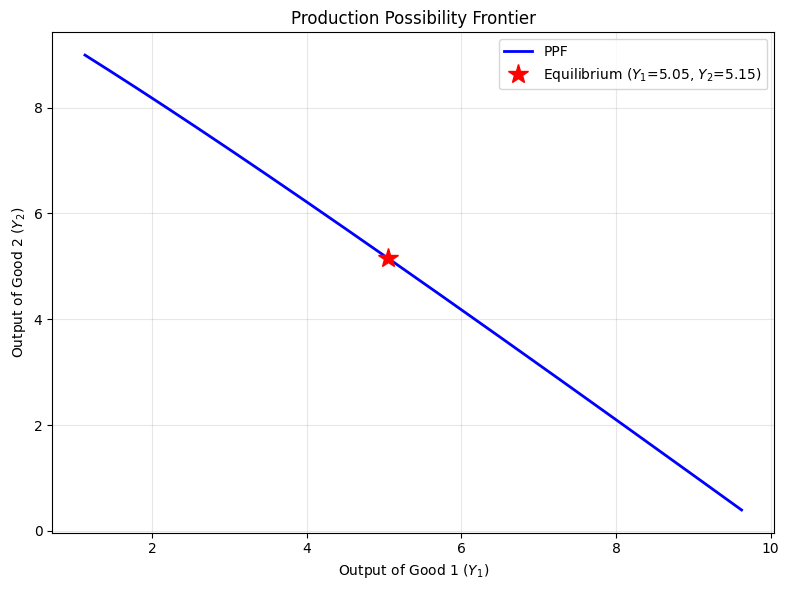


Walras' Law Verification:
  Demand C1 = 5.052597,  Supply Y1 = 5.052597,  ED1 = -9.83e-10
  Demand C2 = 5.151946,  Supply Y2 = 5.151946,  ED2 = 1.22e-10
  p1*ED1 + p2*ED2 = -8.80e-10  (should be ~0)

Interpretation: Walras' law states that the total value of excess
demand across all markets sums to zero. This follows from the
household budget constraint: total spending equals total income,
so if one market has excess demand, another must have excess supply
of equal value. This is an accounting identity, not an equilibrium
condition, and it holds regardless of whether markets clear.


In [11]:
# --- Solution ---

# (a) Define CES production function and marginal products
def ces_output(K, L, A, alpha, rho):
    """CES: Y = A * (alpha*K^rho + (1-alpha)*L^rho)^(1/rho)"""
    return A * (alpha * K**rho + (1 - alpha) * L**rho)**(1.0 / rho)

def ces_mpk(K, L, A, alpha, rho):
    """Marginal product of capital: dY/dK"""
    Z = alpha * K**rho + (1 - alpha) * L**rho
    return A * alpha * K**(rho - 1) * Z**(1.0/rho - 1)

def ces_mpl(K, L, A, alpha, rho):
    """Marginal product of labour: dY/dL"""
    Z = alpha * K**rho + (1 - alpha) * L**rho
    return A * (1 - alpha) * L**(rho - 1) * Z**(1.0/rho - 1)

# Parameters
A1, A2 = 1.0, 1.0
alpha1, alpha2 = 0.4, 0.6
rho1, rho2 = 0.5, -0.5
K_bar, L_bar = 10.0, 10.0
beta_ge = 0.5  # consumer spending share on good 1

print(f"Sector 1: CES with alpha={alpha1}, rho={rho1}, sigma={1/(1-rho1):.1f}")
print(f"Sector 2: CES with alpha={alpha2}, rho={rho2}, sigma={1/(1-rho2):.2f}")
print(f"Endowments: K_bar={K_bar}, L_bar={L_bar}")

# Verify constant returns to scale
t = 2.0
K_test, L_test = 3.0, 4.0
Y_base = ces_output(K_test, L_test, A1, alpha1, rho1)
Y_scaled = ces_output(t*K_test, t*L_test, A1, alpha1, rho1)
print(f"\nCRS check (sector 1): Y(K,L) = {Y_base:.4f}")
print(f"  Y(2K,2L) = {Y_scaled:.4f},  ratio = {Y_scaled/Y_base:.4f} (should be 2.0)")

# (b) Set up and solve general equilibrium
def equilibrium_system(x):
    """System of 3 equations in 3 unknowns: [K1, L1, p]."""
    K1, L1, p = x
    K2 = K_bar - K1
    L2 = L_bar - L1

    # Marginal products
    mpk1 = ces_mpk(K1, L1, A1, alpha1, rho1)
    mpl1 = ces_mpl(K1, L1, A1, alpha1, rho1)
    mpk2 = ces_mpk(K2, L2, A2, alpha2, rho2)
    mpl2 = ces_mpl(K2, L2, A2, alpha2, rho2)

    # Equation 1: rental rate equalisation  r = p*MPK1 = MPK2
    eq1 = p * mpk1 - mpk2
    # Equation 2: wage equalisation  w = p*MPL1 = MPL2
    eq2 = p * mpl1 - mpl2
    # Equation 3: goods market clearing  p*Y1 = beta * Income
    Y1 = ces_output(K1, L1, A1, alpha1, rho1)
    w = mpl2       # wage = p2 * MPL2 (p2 = 1)
    r = mpk2       # rental = p2 * MPK2
    income = w * L_bar + r * K_bar
    eq3 = p * Y1 - beta_ge * income

    return [eq1, eq2, eq3]

# Solve (initial guess: sector 1 is labour-intensive)
x0_ge = [4.0, 6.0, 1.0]
sol_ge = fsolve(equilibrium_system, x0_ge, full_output=True)
x_eq = sol_ge[0]
info = sol_ge[1]
K1_eq, L1_eq, p_eq = x_eq
K2_eq = K_bar - K1_eq
L2_eq = L_bar - L1_eq

Y1_eq = ces_output(K1_eq, L1_eq, A1, alpha1, rho1)
Y2_eq = ces_output(K2_eq, L2_eq, A2, alpha2, rho2)
r_eq = ces_mpk(K2_eq, L2_eq, A2, alpha2, rho2)
w_eq = ces_mpl(K2_eq, L2_eq, A2, alpha2, rho2)

print(f"\n{'='*50}")
print(f"GENERAL EQUILIBRIUM")
print(f"{'='*50}")
print(f"  Sector 1: K1 = {K1_eq:.4f},  L1 = {L1_eq:.4f},  Y1 = {Y1_eq:.4f}")
print(f"  Sector 2: K2 = {K2_eq:.4f},  L2 = {L2_eq:.4f},  Y2 = {Y2_eq:.4f}")
print(f"  Relative price: p = p1/p2 = {p_eq:.4f}")
print(f"  Wage:   w = {w_eq:.4f}")
print(f"  Rental: r = {r_eq:.4f}")
income_eq = w_eq * L_bar + r_eq * K_bar
print(f"  Income: {income_eq:.4f}")

# (c) Production possibility frontier
def compute_ppf():
    """Trace the PPF by finding efficient allocations."""
    Y1_list, Y2_list = [], []
    K1_vals = np.linspace(0.5, K_bar - 0.5, 200)

    for K1 in K1_vals:
        K2 = K_bar - K1
        # Find L1 such that MRTS_1 = MRTS_2 (tangency on contract curve)
        def mrts_diff(L1_val):
            L2_val = L_bar - L1_val
            if L1_val < 0.01 or L2_val < 0.01:
                return 1e10
            mrts1 = (ces_mpk(K1, L1_val, A1, alpha1, rho1) /
                     ces_mpl(K1, L1_val, A1, alpha1, rho1))
            mrts2 = (ces_mpk(K2, L2_val, A2, alpha2, rho2) /
                     ces_mpl(K2, L2_val, A2, alpha2, rho2))
            return mrts1 - mrts2

        try:
            # Initial guess: proportional allocation
            L1_init = L_bar * K1 / K_bar
            L1_init = max(0.5, min(L_bar - 0.5, L1_init))
            L1_sol = fsolve(mrts_diff, L1_init, full_output=True)
            L1 = L1_sol[0][0]
            info_ppf = L1_sol[1]

            if 0.01 < L1 < L_bar - 0.01:
                L2 = L_bar - L1
                Y1_list.append(ces_output(K1, L1, A1, alpha1, rho1))
                Y2_list.append(ces_output(K2, L2, A2, alpha2, rho2))
        except Exception:
            pass

    return Y1_list, Y2_list

Y1_ppf, Y2_ppf = compute_ppf()

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(Y1_ppf, Y2_ppf, 'b-', linewidth=2, label='PPF')
ax.plot(Y1_eq, Y2_eq, 'r*', markersize=15,
        label=f'Equilibrium ($Y_1$={Y1_eq:.2f}, $Y_2$={Y2_eq:.2f})')
ax.set_xlabel(r'Output of Good 1 ($Y_1$)')
ax.set_ylabel(r'Output of Good 2 ($Y_2$)')
ax.set_title('Production Possibility Frontier')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# (d) Verify Walras' law
income = w_eq * L_bar + r_eq * K_bar
C1 = beta_ge * income / p_eq       # demand for good 1
C2 = (1 - beta_ge) * income / 1.0  # demand for good 2 (p2 = 1)

ED1 = C1 - Y1_eq   # excess demand for good 1
ED2 = C2 - Y2_eq   # excess demand for good 2

walras_value = p_eq * ED1 + 1.0 * ED2

print(f"\nWalras' Law Verification:")
print(f"  Demand C1 = {C1:.6f},  Supply Y1 = {Y1_eq:.6f},  ED1 = {ED1:.2e}")
print(f"  Demand C2 = {C2:.6f},  Supply Y2 = {Y2_eq:.6f},  ED2 = {ED2:.2e}")
print(f"  p1*ED1 + p2*ED2 = {walras_value:.2e}  (should be ~0)")

print(f"\nInterpretation: Walras' law states that the total value of excess")
print(f"demand across all markets sums to zero. This follows from the")
print(f"household budget constraint: total spending equals total income,")
print(f"so if one market has excess demand, another must have excess supply")
print(f"of equal value. This is an accounting identity, not an equilibrium")
print(f"condition, and it holds regardless of whether markets clear.")

*End of Problem Set C.*